# Experiment Base

Welcome to the Jupyter Notebook representation of the base of all experiments! This notebook demonstrates the knowhows of running different machine learning experiments on [Malleable Glyphs](https://tmgc.fit.vutbr.cz/). It was created with the intention of being cloned as the base for different experiments.

In [1]:
%reload_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
from dataclasses import dataclass
from pathlib import Path
from pprint import pprint

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from albumentations.pytorch import ToTensorV2
from clearml import Task
from dotenv import load_dotenv
from torch import nn
from torch.utils.data import DataLoader

from mglyph_ml.dataset.glyph_dataset import GlyphDataset
from mglyph_ml.dataset.utils import load_split_samples, show_datasets
from mglyph_ml.experiment.run_config import RunConfigBase
from mglyph_ml.experiment.visualization import show_loss_vs_x_graph, show_truth_vs_pred_graph
from mglyph_ml.nn.glyph_regressor_binned import BinnedGlyphRegressor

# Hyperparameters

Every experiment can run using some set of parameters. These parameters can vary literally anything in the experiment. They can change the shape of the neural network, they can vary the training set, set the learning rate, choose an optimizer, or simply set a random number generator seed. The sky is the limit here.

Notice that this cell has the `parameters` tag associated with it. That tag is very important, because it acts as a 'hook' for a tool called Papermill. This tool injects custom parameters into the notebook and runs it. Injecting parameters is useful because it allows for the execution of series of experiments. We can run the notebook 20 times with different parameters, and analyze the results.

When the notebook is run, it exports important information to the [ClearML web server](https://app.clear.ml/), where the data is aggregated, and can be analyzed. Some parameters like `task_tag` and `task_name` refer to the ClearML Task properties.

*`scheduler_gamma`:*

The gamma is calculated using this formula: $\text{total\_multiplier}^{\frac{1}{\text{total\_steps}}}$. The `total_decrease` corresponds to the total multiplier of the initial learning rate that we wish to be applied, and `total_steps` represents the number of steps necessary to achieve this multiplier. So, for example, if we want our learning rate to decay by a factor of 10 in 1000 steps, we can use $\text{gamma} = \frac{1}{10}^\frac{1}{1000} = \sqrt[1000]{\frac{1}{10}}$.

In [2]:
@dataclass(frozen=True)
class RunConfig(RunConfigBase):
    # The ClearML task tag (so we can easily filter this experiment in the ClearML web GUI).
    task_tag: str = "stability-2"

    # Where the dataset lies.
    dataset_path: Path = Path("data/simple-star.mglyph")

    # This seed is used by every single RNG in the experiment to make it 100% reproducible.
    seed: int = 324

    # We don't have epochs, we only use "steps". 1 step corresponds to the training of the NN on a single batch.
    max_steps: int = 1000

    # The start learning rate. It changes during the experiment because of the LR scheduler.
    learning_rate: float = 0.0005

    # Whether to report the task to ClearML or not. Set to True to stop reporting to ClearML.
    offline: bool = True

    # Size of a single batch that is processed in one step.
    batch_size: int = 64

    # The number of CPU threads spawned to load the data from a PyTorch DataLoader.
    data_loader_num_workers: int = 4

    # In binned regression, this corresponds to the number of divisions of the [0.0; 100.0] interval.
    num_divisions: int = 5

    # This parameter is used to reduce the number of samples used during training, for debugging purposes.
    sample_count: int = 9999999999

    # How fast the learning rate decays.
    # scheduler_gamma: float = (1 / 10) ** (1 / 1000)

    # Optional explicit name; if None, it is derived from other fields below.
    task_name: str = f"Stability 2 [seed={seed},lr={learning_rate}]"

# Here, we clear the global variables that have the same names as the fields in this RunConfig class.
RunConfig.clear_globals()

{'batch_size',
 'data_loader_num_workers',
 'dataset_path',
 'learning_rate',
 'max_steps',
 'num_divisions',
 'offline',
 'sample_count',
 'seed',
 'task_name',
 'task_tag'}

In [3]:
# This is the global RunConfig instance. You can use c.xxx to access the `xxx` parameter.
c = RunConfig.from_globals()

Task.set_offline(c.offline)
task: Task = Task.init(project_name="mglyph-ml", task_name=c.task_name)
task.add_tags(c.task_tag)
task.connect(c)

load_dotenv()
pprint(c)

ClearML Task: created new task id=offline-b9db80d8942f4fe9b3ff7aac528aae3a
ClearML running in offline mode, session stored in /home/xgaens00/.clearml/cache/offline/offline-b9db80d8942f4fe9b3ff7aac528aae3a
RunConfig(task_tag='stability-2',
          dataset_path=PosixPath('data/simple-star.mglyph'),
          seed=324,
          max_steps=1000,
          learning_rate=0.0005,
          offline=True,
          batch_size=64,
          data_loader_num_workers=4,
          num_divisions=5,
          sample_count=9999999999,
          task_name='Stability 2 [seed=324,lr=0.0005]')


# Data Loading

The data is loaded from the dataset file from so-called _splits_. You can think of a split like a folder inside the dataset; it's simply used to group a bunch of samples together. A single sample inside the dataset has these properties:

- `label`: the real x-value of the glyph (sample)
- `image`: this is the binary data of the glyph itself
- (optional) `metadata`: this is an arbitrary `dict` containing some useful information the creator of the dataset wanted to embed into it

In [4]:
loaded_split_0 = load_split_samples(
    dataset_path=c.dataset_path,
    split="0",
    desired_size=(64, 64),
    shuffle=True,
    seed=c.seed,
)

train_limit = min(c.sample_count, len(loaded_split_0))
samples_train = loaded_split_0[:train_limit]
images_train = [s.image for s in samples_train]
labels_train = [s.label for s in samples_train]

# Augmentation

When training the neural network, we can _augment_ the samples, which is a fancy word for modifying them a bit to make the samples a bit harder for the neural network to learn from. In this simple case, we simply rotate them a bit and move them around a tiny bit. This way, the NN cannot rely on simple patterns like a single line through the image, but has to find other, more complex ways to predict the correct label.

# GlyphDataset

This class is a data structure that holds a series of samples and labels, and applies some kind of transformation to them. We need this class because PyTorch provides a `DataLoader` class whose constructor needs an instance of a `Dataset` class. By following PyTorch's recommended data loading procedures, we gain access to automatic optimizations which include caching, thus, making the training faster.

In [5]:
affine = A.Affine(
    rotate=(-3, 3),
    translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
    fit_output=False,
    keep_ratio=True,
    border_mode=cv2.BORDER_CONSTANT,
    fill=255,
    p=1.0,
)
normalize = A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0)
to_tensor = ToTensorV2()
pipeline = A.Compose([affine, normalize, to_tensor], seed=c.seed)
normalize_pipeline = A.Compose([normalize, to_tensor])


def affine_and_normalize(image: np.ndarray) -> torch.Tensor:
    return pipeline(image=image)["image"]


def just_normalize(image: np.ndarray) -> torch.Tensor:
    return normalize_pipeline(image=image)["image"]


dataset_train = GlyphDataset(
    name="Training",
    images=images_train,
    labels=labels_train,
    transform=just_normalize,
)

print(f"train dataset size: {len(dataset_train)}")

train dataset size: 10002


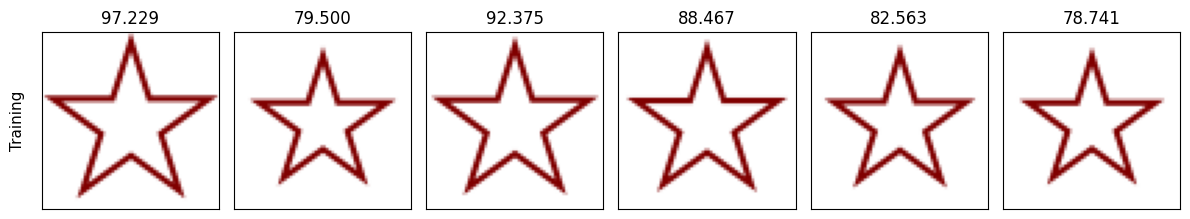

In [6]:
show_datasets(dataset_train)

# Model

Here, we initialize the model and other important objects required during training. The DataLoader is also created here. The reason why it is not created right after the creation of the `GlyphDataset` is because we want to re-create the DataLoader when we want to re-create the model from scratch. The `GlyphDataset` never changes, it holds no mutable state. However, the `DataLoader` needs a seed which feeds a RNG inside the `DataLoader`. If we want to deterministically re-create the training, we need to reset the `DataLoader`.

The `scheduler` is an object responsible for the changing of the learning rate during training.

In [7]:
device = os.environ["MGML_DEVICE"]
print(f"Training device: {device}")

model = BinnedGlyphRegressor(num_divisions=c.num_divisions)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=c.learning_rate)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=c.scheduler_gamma)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=700, gamma=0.5)
generator = torch.Generator().manual_seed(c.seed)

data_loader_train = DataLoader(
    dataset_train,
    batch_size=c.batch_size,
    num_workers=c.data_loader_num_workers,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True,
    generator=generator,
)

Training device: cuda:2


# Training

The training is done in _steps_. One step corresponds to a single batch processed by the NN (with the update of the NN's weights). In this example, we don't even have epochs. Everything is done in steps. At the beginning of the cell, we create a `train_iterator`, which is an iterator that can fetch training samples from the training `DataLoader`. Once this iterator is exhausted, it's reset to the beginning and looped through again. This way, we can train indefinitely and the learning curve is not dependent on the amount of samples we're training on. However, it's still dependent on the batch size. If we increase the batch side, the number of steps required to go through the entire training set gets lower, because we're crunching through the dataset at a quicker rate.

In [8]:
from collections import deque

model.to(device)

step = 0
running_loss_train = 0.0
running_error_train = 0.0
num_batches_train = 0

recent_train_losses = deque(maxlen=20)

train_iterator = iter(data_loader_train)

while step < c.max_steps:
    model.train()

    try:
        inputs, labels = next(train_iterator)
    except StopIteration:
        train_iterator = iter(data_loader_train)
        inputs, labels = next(train_iterator)

    inputs = inputs.to(device, non_blocking=True).float()
    labels = labels.to(device, non_blocking=True).float().view(-1)

    optimizer.zero_grad()
    logits: torch.Tensor = model(inputs)
    preds = model.logits_to_labels(logits)

    loss = criterion(preds, labels)
    loss.backward()
    optimizer.step()
    scheduler.step()

    error = torch.mean(torch.abs(preds - labels)).item()

    running_loss_train += loss.item()
    running_error_train += error
    num_batches_train += 1
    recent_train_losses.append(loss.item())
    step += 1

    if step % 100 == 0 or step == c.max_steps:
        avg_recent_loss = sum(recent_train_losses) / len(recent_train_losses)
        print("=" * 80)
        print(
            f"Step {step}: loss(last {len(recent_train_losses)} avg)={avg_recent_loss:.6f}, "
            f"lr={scheduler.get_last_lr()[0]:.6f}"
        )

Step 100: loss(last 20 avg)=0.630707, lr=0.000500
Step 200: loss(last 20 avg)=0.035520, lr=0.000500
Step 300: loss(last 20 avg)=0.022204, lr=0.000500
Step 400: loss(last 20 avg)=0.006092, lr=0.000500
Step 500: loss(last 20 avg)=0.012447, lr=0.000500
Step 600: loss(last 20 avg)=0.004798, lr=0.000500
Step 700: loss(last 20 avg)=0.011404, lr=0.000250
Step 800: loss(last 20 avg)=0.001596, lr=0.000250
Step 900: loss(last 20 avg)=0.001584, lr=0.000250
Step 1000: loss(last 20 avg)=0.001735, lr=0.000250


Here, we show a graph which shows the real value of x vs. the predicted one. All the points on this graph should fall as close to the $y = x$ line as possible.

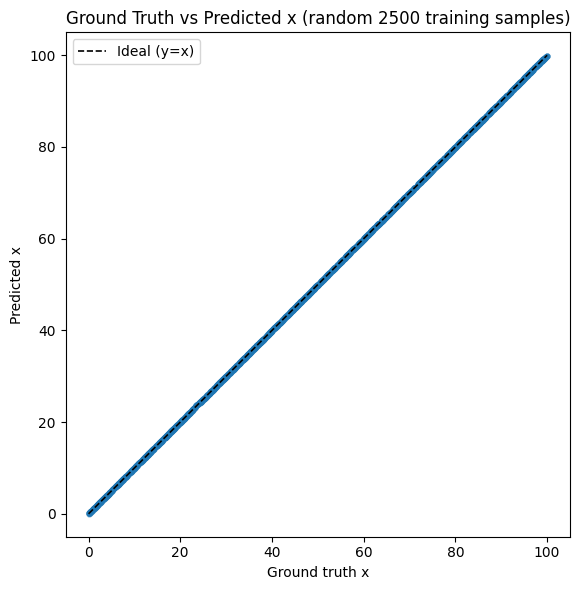

In [9]:
fig, ax = show_truth_vs_pred_graph(
    n_samples=2500,
    model=model,
    seed=c.seed,
    dataset=dataset_train,
    device=device,
)

Worst 5 losses: [0.02121473 0.02344867 0.03144323 0.03602849 0.03775163]
Worst 5 average loss: 0.029977


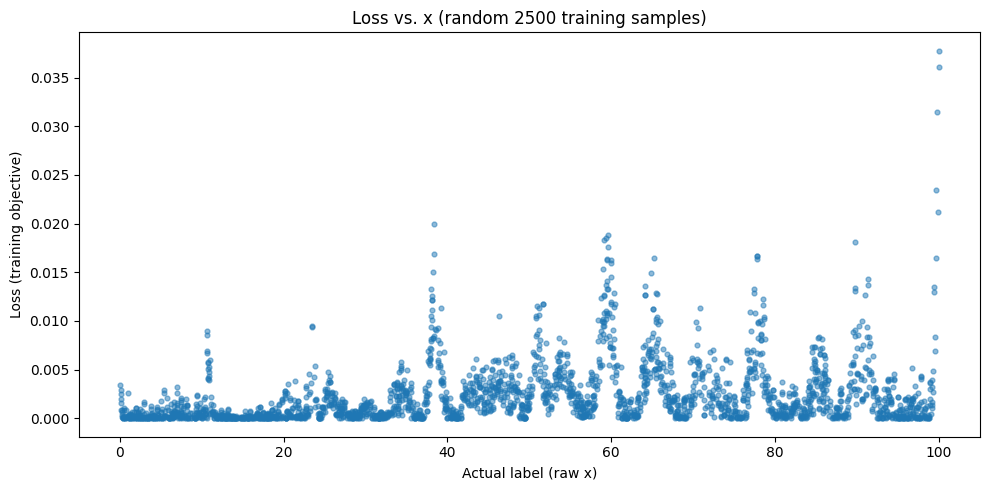

In [10]:
fig, ax, worst_5_loss_avg, worst_5_losses = show_loss_vs_x_graph(
    n_samples=2500,
    model=model,
    dataset=dataset_train,
    device=device,
    loss_fn=criterion,
    seed=c.seed,
)

task.logger.report_scalar(
    title="Evaluation",
    series="Worst 5 Loss Avg",
    value=worst_5_loss_avg,
    iteration=c.max_steps,
)

print(f"Worst 5 losses: {worst_5_losses}")
print(f"Worst 5 average loss: {worst_5_loss_avg:.6f}")

In [11]:
task.flush(wait_for_uploads=True)
task.close()

ClearML Task: Offline session stored in /home/xgaens00/.clearml/cache/offline/offline-b9db80d8942f4fe9b3ff7aac528aae3a.zip
